In [1]:
# Import Packages
import os
import re
import sys
import time
import copy
from pathlib import Path
from IPython.display import display

import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import boxcox

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import r2_score, mean_squared_error

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, GroupKFold
from sklearn.model_selection import RepeatedKFold

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, RidgeCV

from sklearn.feature_selection import VarianceThreshold

from itertools import product

#%load_ext autoreload
#%reload_ext autoreload
#%autoreload 2
#from model_functions import *

%run Model_functions.ipynb

In [2]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

!chmod 644 ~/.local/share/jupyter/history.sqlite
#!rm ~/.local/share/jupyter/history.sqlite

chmod: /Users/kosaraju_b/.local/share/jupyter/history.sqlite: No such file or directory


# DOWNLOAD NISAR-AGB-CANOPY DATA

In [3]:
NISAR_DATA_CSV = "../../DATA/AGB_DATA/Merged_Data/NISAR/Nisar_AGB_CANOPY.csv"

nisar_df = pd.read_csv(NISAR_DATA_CSV)
print(nisar_df.shape)
nisar_df.columns

(3176, 15)


Index(['dataset', 'plot_id', 'start_date', 'end_date', 'latitude', 'longitude',
       'diameter', 'height', 'species', 'plant_AGB_kg', 'date',
       'nisar_value_hvhv', 'nisar_value_hhhh', 'simard_height_m',
       'tandemx_height_m'],
      dtype='object')

In [4]:
assert len(nisar_df["simard_height_m"].head())
assert len(nisar_df["tandemx_height_m"].head())

In [5]:
nisar_df['dataset'].unique()

array(['ElSalvador', 'Brazil-Mangue', 'Brazil-Furo_Do_Chato',
       'Brazil-Maruipe', 'Brazil-BocaGrande', 'Brazil-Barreto',
       'Brazil-Salinas', 'Brazil-FuroGrande', 'Brazil-Caetano'],
      dtype=object)

### Select features

In [19]:
non_feature_cols = [
    #'plant_AGB_kg',       # Target variable
    'dataset',             # metadata
    'start_date',          # metadata
    'end_date',            # metadata
    'capture_start',       # metadata
    'capture_end',         # metadata
    'latitude',           # coordinate
    'longitude',          # coordinate
    'diameter',            # Allometric
    'height',              # Allometric
    'cloud_threshold_used'
]

nisar_bands = ['nisar_value_hhhh', 'nisar_value_hvhv']
useful_categorical = ['plot_id', 'species']
struct_features = ['height']

target = 'plant_AGB_kg'
feature_cols = [c for c in nisar_df.columns if c not in non_feature_cols]

X = nisar_df[feature_cols]
y = nisar_df[target]

# Select TANDEMX
X = X.rename({'tandemx_height_m': 'height'}, axis=1)
X = X.drop(columns=['simard_height_m'])

# Select SIMARD
#X = X.rename({'simard_height_m': 'height'}, axis=1)
#X = X.drop(columns=['tandemx_height_m'])

print(f"Features: {feature_cols}")

Features: ['plot_id', 'species', 'plant_AGB_kg', 'date', 'nisar_value_hvhv', 'nisar_value_hhhh', 'simard_height_m', 'tandemx_height_m']


In [13]:
# Retain the groups/plot_id for splitting the data based on groups.
plot_groups = X['plot_id'].copy()
site_groups = plot_groups.map(lambda x: x.rsplit('_', maxsplit=1)[0])

## DATA PREPROCESSING

In [14]:
null_rows   = X[X.isnull().any(axis=1)]
total_nulls = X.isnull().sum().sum()

print(f"Total NULL count           : {total_nulls}")
print(f"Rows with at least one NULL: {len(null_rows)}")
print(f"Total rows                 : {len(X)}")
print(f"Percentage                 : {len(null_rows)/len(X)*100:.1f}%")

# NULL count per column for only the affected rows
null_col_counts = null_rows.isnull().sum().sort_values(ascending=False)
print("\nNULL count per column in affected rows:")
print(null_col_counts[null_col_counts > 0])

Total NULL count           : 0
Rows with at least one NULL: 0
Total rows                 : 3176
Percentage                 : 0.0%

NULL count per column in affected rows:
Series([], dtype: int64)


In [18]:
assert not total_nulls
#X = handle_null_data(X)
#X = X.dropna()
#print(X.shape)
#X.columns

### Find correlations

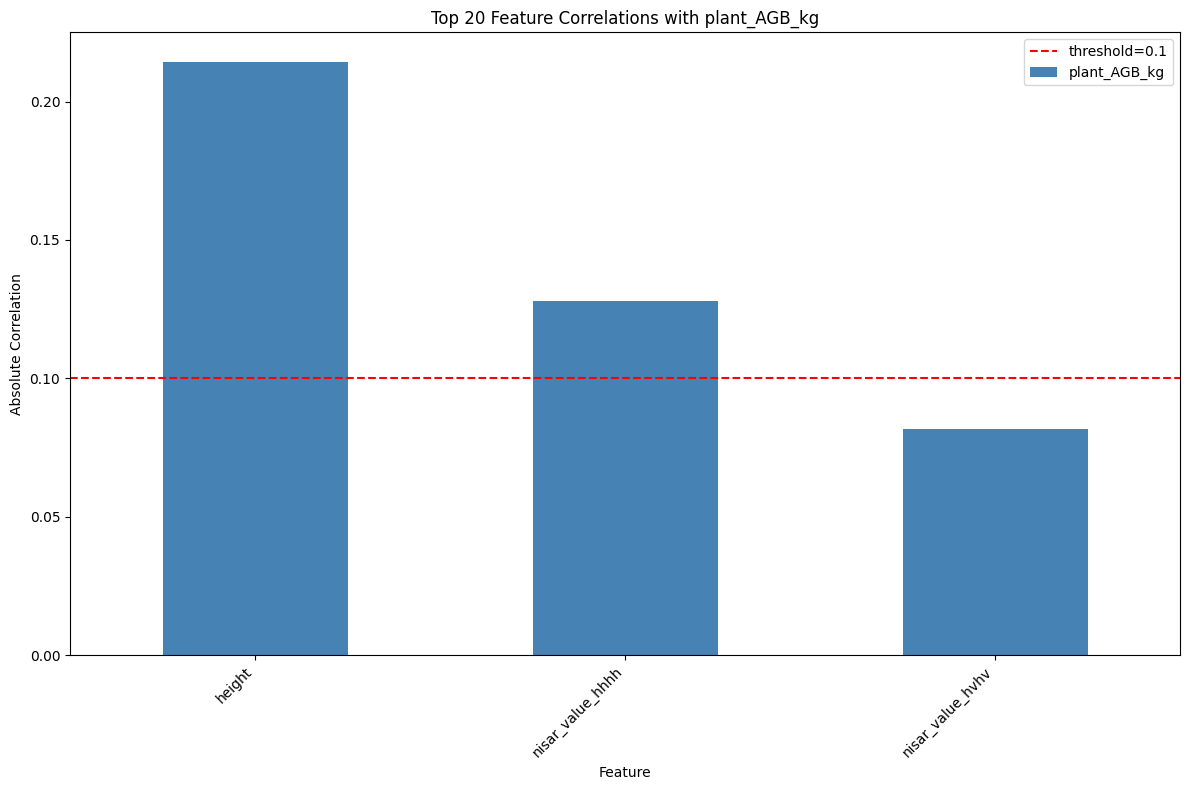

height              0.214328
nisar_value_hhhh    0.127950
nisar_value_hvhv    0.081804
Name: plant_AGB_kg, dtype: float64


In [16]:
numerical_cols = get_numerical_cols(X)
target_corr = plot_correlation_matrix(X[numerical_cols],
                                      X['plant_AGB_kg'],
                                      top_n=20)
print(target_corr)

**COMMENTS:**  
Columns with a Pearson correlation coefficient (r) between -0.1 and 0.1 with the target variable are generally considered to have a negligible or very weak relationship.

### Remove Low Variance Features (cols)

#### Is variance threshold valid for sentinel-2 data?

- Sentinel-2 surface reflectance values are typically in the range 0.0 to 0.3.  
 - Their absolute variance is naturally small — not because they carry no information but because their scale is small.  
 - A feature with values ranging from 0.05 to 0.25 has variance of ~0.003, which falls below the 0.01 threshold, but the variation within that range is meaningful for AGB prediction.  
 - VarianceThreshold is designed for features with near-identical values across all rows — like a binary column that is always 0.  
 - It is not appropriate for bounded continuous features like reflectance values.

### Remove Features With Weak Correlation to Target

#### Why Pearson correlation is unreliable here?

Pearson correlation measures linear relationship between a feature and the target. 

The above correlation removal process is based on the correlations computed against the original y. But we are going log-transform the target for modeling. 

A feature can have a strong non-linear relationship with AGB that shows up clearly after log transformation but appears weak in linear correlation against raw AGB.  

The experiments (Belige-data-analysis.ipynb) already proved these features are useful.  

In [ ]:
X = remove_uncorrelated_categorical_cols(X, y)
assert X is not None

X.columns

### Convert categorical variables to one-hot encoding

# What would actually constitute a good result?
For a model to be trustworthy you would want to see:
 - Grouped CV mean above 0.40
 - Grouped CV std below 0.15
 - No individual grouped CV fold below -0.10
 - Regular CV and grouped CV in the same ballpark — large divergence between them signals leakage
 - Test R² close to grouped CV mean, not far above it

**Determine near_zero_threshold, and high_agb_threshold**  
**near_zero_threshold = 1.0 kg**
 - Any site where the heaviest plant weighs less than 1 kg has near-zero AGB variance.
 - From your data Frenchman Caye (max 0.26 kg) and Shipstern (max 0.94 kg) fall below this.
 - R² is meaningless for these sites as a holdout set.
 - In other words, R² is mathematically unstable when the holdout set has near-zero variance.

**R² is defined as:** 1 - (sum of squared residuals / total sum of squares)
**Total sum of squares is (denominator):** sum of (y - mean(y))²
**Problem:**  
 - When every plant in the holdout site weighs between 0.001 and 0.26 kg, the mean is ~0.03 kg and every value is very close to that mean.
 - This makes the total sum of squares as near-zero.
 - Any prediction error, however small will produce a large negative R² because of the near-zero denominator.

**high_agb_threshold = 100.0 kg**
 - Any site with trees above 100 kg is potentially ecologically distinct from the rest.
 - From your data Channel Caye (max 427 kg) and New River (max 261 kg) fall above this.
 - These are the sites where generalization failure is a genuine concern.

In [20]:
%run Model_functions.ipynb

In [21]:
near_zero_sites, high_agb_sites, near_zero_plots, high_agb_plots = \
    get_low_and_high_agb_plots(y, plot_groups)

High-AGB threshold  : 3110.16 kg
Near-zero threshold : 0.002791

Near-zero variance plots:

High-AGB plots:
  BOC_Boca Grande           : max AGB = 5572.3 kg
  CAE_Caetano               : max AGB = 5248.5 kg
  El_Plan_de_la_Ceiba_8_1   : max AGB = 5199.1 kg
  El_Plan_de_la_Ceiba_8_3   : max AGB = 3403.8 kg
  El_Plan_de_la_Ceiba_8_6   : max AGB = 5765.0 kg
  MAN_Mangue Sul            : max AGB = 7172.7 kg
  Montecristo_21_2          : max AGB = 4711.5 kg
  Montecristo_21_3          : max AGB = 5765.0 kg
  Montecristo_22_2          : max AGB = 9617.2 kg
  Montecristo_22_3          : max AGB = 11337.3 kg
  Montecristo_22_4          : max AGB = 3179.8 kg
Bordo_del_Chile_23   : within-site high-AGB plots = ['Bordo_del_Chile_23_2']
Santo_Domingo_5      : within-site high-AGB plots = ['Santo_Domingo_5_2']
El_Espino_6          : within-site high-AGB plots = ['El_Espino_6_1']
La_Herradura_7       : within-site high-AGB plots = ['La_Herradura_7_2']
San_Antonio_Los_Blancos_12 : within-site high-A

In [22]:
features_list = [struct_features, 
                 struct_features + useful_categorical,
                 struct_features + nisar_bands,
                 nisar_bands,
                 nisar_bands + useful_categorical,
                 nisar_bands + struct_features + useful_categorical]

model_list = ["regular", "ridge", "lasso", "elasticnet"]

test_cv = 5
#test_cv = RepeatedKFold(n_splits=5, n_repeats=10, random_state=42)

# LINEAR REGRESSION

In [23]:
%run Model_functions.ipynb
lin_experiments = {}

In [24]:
def run_lin_experiment(model_type, X_df, y, features,
                       is_groups, groups, test_cv, idx,label_in):
    label = f"EXPERIMENT-{idx} {label_in}, Model: {model_type}, Features: {features}"
    
    X = X_df[features]
    categorical_cols = get_categorical_cols(X)
    if categorical_cols:
        X = pd.get_dummies(X, columns=categorical_cols, dtype=int)

    if is_groups:
        results = linear_reg_groups(model_type, X, y, test_cv, groups, label)
    else:
        results = linear_reg_regular(model_type, X, y, test_cv, label)
    lin_experiments[label] = results

    if is_groups:
        evaluate_experiment(label="",
                            results=results,
                            fold_sites=results["fold_sites"],
                            near_zero_sites=near_zero_sites,
                            high_agb_sites =high_agb_sites)
    else:
        evaluate_experiment(label="",
                            results=results,
                            fold_sites=None,
                            near_zero_sites=near_zero_plots,
                            high_agb_sites =high_agb_plots)

In [25]:
def lin_experiment(is_groups, groups, label):
    total     = len(features_list) * len(model_list)
    completed = 0

    for (feat_idx, features), (model_type) in product(enumerate(features_list), model_list):
        completed += 1
        print(f"\n[{completed}/{total}]")
    
        try:
            run_lin_experiment(model_type, X, y, features,
                               is_groups, groups, test_cv,
                               completed, label)        
        except Exception as e:
            print(f"  ERROR: {e}")
    
    print(f"\nCompleted: {completed}/{total} experiments")

### Linear regression without groups.

In [26]:
lin_experiment(is_groups=False, groups=plot_groups, label="No groups")
# 1st-EXPERIMENT: No groups. Linear regression variants.


[1/24]

 EXPERIMENT-1 No groups, Model: regular, Features: ['height'], ALGO: LINEAR REGRESSION: 
Test R²     : -0.0499
Test RMSE   : 453.88 kg
Train R² (log scale): 0.0135
Train R² (orig scale): -0.0450
Train RMSE  : 569.50 kg
Num Features: 1

 Cross-validation ---
CV R² mean: 0.0069
CV R² std : 0.0103
CV scores : [ 0.017  0.006 -0.008 -0.     0.02 ]
EXPERIMENT EVALUATION: 

Test set:
  R²   : -0.050
  RMSE : 453.88 kg

Regular CV:
  Mean   : 0.007
  Std    : 0.010
  Scores : [ 0.017  0.006 -0.008 -0.     0.02 ]

  ❌ Test R² is negative (-0.050)
  ✅ CV mean is positive (0.007)

────────────────────────────────────────────────────────────
VERDICT: ❌ NOT ACCEPTABLE

[2/24]

 EXPERIMENT-2 No groups, Model: ridge, Features: ['height'], ALGO: RIDGE REGRESSION: 
Test R²     : -0.0501
Test RMSE   : 453.91 kg
Train R² (log scale): 0.0135
Train R² (orig scale): -0.0452
Train RMSE  : 569.56 kg
Num Features: 1

 Cross-validation ---
CV R² mean: 0.0070
CV R² std : 0.0096
CV scores : [ 0.016  0.00

### Linear regression with PLOT groups.

In [27]:
%run Model_functions.ipynb
lin_experiment(is_groups=True, groups=plot_groups, label="Grouping: Plots")
# 2nd-EXPERIMENT: Plot level groups. Linear regression variants.


[1/24]

 EXPERIMENT-1 Grouping: Plots, Model: regular, Features: ['height'], ALGO: LINEAR REGRESSION: 
Test R²     : -0.0195
Test RMSE   : 464.79 kg
Train R² (log scale): 0.0013
Train R² (orig scale): -0.0543
Train RMSE  : 568.10 kg
Num Features: 1

 Cross-validation ---
CV R² mean: -1.1421
CV R² std : 1.7725
CV scores : [-0.165 -0.465 -0.036 -4.674 -0.371]

Grouped Cross-validation ---
Grouped CV R² mean: -0.1204
Grouped CV R² std : 0.1274
Grouped CV scores : [-0.075 -0.088 -0.006 -0.231 -0.016 -0.155 -0.153 -0.437 -0.002 -0.039]
EXPERIMENT EVALUATION: 

Test set:
  R²   : -0.019
  RMSE : 464.79 kg

Regular CV:
  Mean   : -1.142
  Std    : 1.772
  Scores : [-0.165 -0.465 -0.036 -4.674 -0.371]

  ❌ Test R² is negative (-0.019)
  ❌ CV mean is negative (-1.142)

Grouped CV:
  Los_Mapaches-El_Chile_24_2 :  -0.075  ❌ negative — cause unknown
  Montecristo_21_5     :  -0.088  ❌ negative — cause unknown
  Montecristo_21_4     :  -0.006  ❌ negative — cause unknown
  Montecristo_22_5     :  -

### Linear regression with SITE groups.

In [28]:
lin_experiment(is_groups=True, groups=site_groups, label="Grouping: Sites")
# 3rd-EXPERIMENT: Site level groups. Linear regression variants.


[1/24]

 EXPERIMENT-1 Grouping: Sites, Model: regular, Features: ['height'], ALGO: LINEAR REGRESSION: 
Test R²     : -0.0377
Test RMSE   : 385.97 kg
Train R² (log scale): 0.0107
Train R² (orig scale): -0.0482
Train RMSE  : 582.63 kg
Num Features: 1

 Cross-validation ---
CV R² mean: -1.1433
CV R² std : 1.6753
CV scores : [-0.212 -0.571 -0.162 -4.482 -0.29 ]

Grouped Cross-validation ---
Grouped CV R² mean: -3.8914
Grouped CV R² std : 11.0273
Grouped CV scores : [-6.4000e-01 -3.6967e+01 -5.5000e-02 -5.8100e-01  1.0000e-02 -8.3000e-02
 -1.0000e-02 -2.5800e-01 -1.3700e-01 -1.9300e-01]
EXPERIMENT EVALUATION: 

Test set:
  R²   : -0.038
  RMSE : 385.97 kg

Regular CV:
  Mean   : -1.143
  Std    : 1.675
  Scores : [-0.212 -0.571 -0.162 -4.482 -0.29 ]

  ❌ Test R² is negative (-0.038)
  ❌ CV mean is negative (-1.143)

Grouped CV:
  Isla_Tortuga_26      :  -0.640  ❌ negative — cause unknown
  El_Cañón_del_Bagre_17 : -36.967  ❌ negative — cause unknown
  El_Jobal_27          :  -0.055  ❌ negat

# RANDOM FOREST

In [29]:
%run Model_functions.ipynb
rf_experiments = {}

In [30]:
def run_rf_experiment(X_df, y, features,
                      is_groups, groups, test_cv,
                      idx,label_in):
    label = f"EXPERIMENT-{idx} {label_in}, Features: {features}."
    
    X = X_df[features]
    categorical_cols = get_categorical_cols(X)
    if categorical_cols:
        X = pd.get_dummies(X, columns=categorical_cols, dtype=int)

    if is_groups:
        results = randomForest_groups(X, y, test_cv, groups, label, False, True)
    else:
        results = randomForest_regular(X, y, test_cv, label, False, True)

    rf_experiments[label] = results
    if is_groups:
        show_importances(results)

    fold_sites = None
    if is_groups:
        fold_sites = results["fold_sites"]
        
    if is_groups:
        evaluate_experiment(label=label,
                            results=results,
                            fold_sites=results["fold_sites"],
                            near_zero_sites=near_zero_sites,
                            high_agb_sites =high_agb_sites)
    else:
        evaluate_experiment(label=label,
                            results=results,
                            fold_sites=None,
                            near_zero_sites=near_zero_plots,
                            high_agb_sites =high_agb_plots)

In [31]:
def rf_experiment(is_groups, groups, label):
    total     = len(features_list)
    completed = 0

    for features in features_list:
        completed += 1
        print(f"\n[{completed}/{total}]")

        try:
            run_rf_experiment(X, y, features,
                              is_groups, groups, test_cv,
                              completed, label)
        except Exception as e:
            print(f"  ERROR: {e}")

    print(f"\nCompleted: {completed}/{total} experiments")

### RANDOM FOREST WITHOUT GROUPS

In [32]:
rf_experiment(is_groups=False, groups=plot_groups, label="No groups")
#4th-EXPERIMENT: No groups. RANDOM FOREST.


[1/6]

 RANDOM FOREST: EXPERIMENT-1 No groups, Features: ['height'].
Test R²     : -0.0153
Test RMSE   : 446.34 kg
Train R² (log scale): 0.4168
Train R² (orig scale): 0.0246
Train RMSE  : 550.20 kg
Num Features: 1

 Cross-validation ---
CV R² mean: 0.3672
CV R² std : 0.0678
CV scores : [0.416 0.388 0.449 0.259 0.324]
EXPERIMENT EVALUATION: EXPERIMENT-1 No groups, Features: ['height'].

Test set:
  R²   : -0.015
  RMSE : 446.34 kg

Regular CV:
  Mean   : 0.367
  Std    : 0.068
  Scores : [0.416 0.388 0.449 0.259 0.324]

  ❌ Test R² is negative (-0.015)
  ✅ CV mean is positive (0.367)

────────────────────────────────────────────────────────────
VERDICT: ❌ NOT ACCEPTABLE

[2/6]

 RANDOM FOREST: EXPERIMENT-2 No groups, Features: ['height', 'plot_id', 'species'].
Test R²     : 0.0087
Test RMSE   : 441.02 kg
Train R² (log scale): 0.5571
Train R² (orig scale): 0.0441
Train RMSE  : 544.69 kg
Num Features: 148

 Cross-validation ---
CV R² mean: 0.4624
CV R² std : 0.0356
CV scores : [0.459 0.4

### RANDOM FOREST WITH PLOT GROUPS

In [33]:
rf_experiment(is_groups=True, groups=plot_groups, label="Grouping: Plots")
# 5th-EXPERIMENT: Plot level groups. RANDOM FOREST.


[1/6]

 RANDOM FOREST: EXPERIMENT-1 Grouping: Plots, Features: ['height'].
Test R²     : -0.0107
Test RMSE   : 462.78 kg
Train R² (log scale): 0.4157
Train R² (orig scale): 0.0213
Train RMSE  : 547.35 kg
Num Features: 1

 Cross-validation ---
CV R² mean: -2.0559
CV R² std : 0.7469
CV scores : [-1.963 -2.052 -2.06  -3.28  -0.923]

Grouped Cross-validation ---
Grouped CV R² mean: 0.0156
Grouped CV R² std : 0.2488
Grouped CV scores : [-0.354 -0.083  0.345 -0.005 -0.344 -0.029  0.317 -0.178  0.225  0.262]

Top 10 feature importances:
  height                                        1.0000  ██████████████████████████████████████████████████
EXPERIMENT EVALUATION: EXPERIMENT-1 Grouping: Plots, Features: ['height'].

Test set:
  R²   : -0.011
  RMSE : 462.78 kg

Regular CV:
  Mean   : -2.056
  Std    : 0.747
  Scores : [-1.963 -2.052 -2.06  -3.28  -0.923]

  ❌ Test R² is negative (-0.011)
  ❌ CV mean is negative (-2.056)

Grouped CV:
  Los_Mapaches-El_Chile_24_2 :  -0.354  ❌ negative — cause 

### RANDOM FOREST WITH SITE GROUPS

In [34]:
rf_experiment(is_groups=True, groups=site_groups, label="Grouping: Sites")
#6th-EXPERIMENT: Site level groups. RANDOM FOREST.


[1/6]

 RANDOM FOREST: EXPERIMENT-1 Grouping: Sites, Features: ['height'].
Test R²     : -0.0116
Test RMSE   : 381.09 kg
Train R² (log scale): 0.4168
Train R² (orig scale): 0.0141
Train RMSE  : 565.05 kg
Num Features: 1

 Cross-validation ---
CV R² mean: -1.8021
CV R² std : 1.3925
CV scores : [-2.051 -0.09  -1.757 -4.224 -0.888]

Grouped Cross-validation ---
Grouped CV R² mean: -6.2892
Grouped CV R² std : 11.6422
Grouped CV scores : [-2.1823e+01 -3.5621e+01 -7.4100e-01 -6.6400e-01 -1.8340e+00 -2.4900e-01
 -7.0200e-01 -9.1500e-01 -3.5800e-01  1.5000e-02]

Top 10 feature importances:
  height                                        1.0000  ██████████████████████████████████████████████████
EXPERIMENT EVALUATION: EXPERIMENT-1 Grouping: Sites, Features: ['height'].

Test set:
  R²   : -0.012
  RMSE : 381.09 kg

Regular CV:
  Mean   : -1.802
  Std    : 1.392
  Scores : [-2.051 -0.09  -1.757 -4.224 -0.888]

  ❌ Test R² is negative (-0.012)
  ❌ CV mean is negative (-1.802)

Grouped CV:
  Isla